# VoltGuard AI: Context-Aware IoT Cyber Activity Detection

**Author:** Aseel Almutairi  
**Dataset:** TON-IoT Network Dataset  
**Task:** Binary Classification — Normal vs. Attack  
**Primary Metric:** F1-Score

---

## 1. Introduction

IoT devices are deployed across homes, hospitals, industrial systems, and smart cities. Unlike traditional computers, most IoT devices lack built-in security software, making them attractive targets for attackers. Common attacks against IoT networks include backdoors, distributed denial-of-service (DDoS), scanning, password attacks, injection, ransomware, and man-in-the-middle attacks.

**VoltGuard AI** is a machine learning system designed to detect abnormal behavior in IoT network traffic. It analyzes network traffic features, system activity, device telemetry, and contextual metadata to classify each network event as either **Normal** or **Attack**.

**Classification Goal:** Predict `label` — where 0 = Normal and 1 = Attack.

**Why this matters:** Missed attacks in IoT networks can lead to data breaches, ransomware, and physical damage to infrastructure. Automated detection enables rapid response.

**Primary metric:** F1-score, because the dataset is class-imbalanced (~50K Normal, ~161K Attack). Accuracy alone is misleading for imbalanced data.

---
## 2. Import Libraries

In [7]:
# Standard data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score
)

# Saving models
import joblib
import json
import os

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Create output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("All libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

All libraries loaded successfully.
TensorFlow version: 2.16.2
scikit-learn version: 1.7.1


---
## 3. Load Dataset

In [8]:
# IMPORTANT: encoding='utf-8-sig' strips the BOM character (\ufeff)
# from the first column name in this CSV file.
# Without it, the first column is named '\ufeffsrc_ip' and all
# references to 'src_ip' will raise a KeyError.
DATA_PATH = '/Users/aseelalmitari/Downloads/capstone_ASEEL_ALMUTAIRI/data/train_test_network.csv'

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn names ({len(df_raw.columns)} total):")
print(list(df_raw.columns))

Dataset shape: (211043, 44)

Column names (44 total):
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']


In [9]:
print("First 5 rows:")
df_raw.head()

First 5 rows:


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.3715,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.0001,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.0001,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.0001,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.0001,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor


In [10]:
print("Data types:")
df_raw.dtypes

Data types:


src_ip                     object
src_port                    int64
dst_ip                     object
dst_port                    int64
proto                      object
service                    object
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                 object
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                  object
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                     object
dns_RD                     object
dns_RA                     object
dns_rejected               object
ssl_version                object
ssl_cipher                 object
ssl_resumed                object
ssl_established            object
ssl_subject                object
ssl_issuer                 object
http_trans_dep

In [11]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

---
## 4. Data Quality Checks

In [12]:
# 4.1 Check for NaN values
nan_counts = df_raw.isna().sum()
print("NaN values per column:")
if nan_counts.sum() > 0:
    print(nan_counts[nan_counts > 0])
else:
    print("No NaN values found.")

NaN values per column:
No NaN values found.


In [13]:
# 4.2 Check for '-' placeholder values (the real missing data indicator)
# The TON-IoT dataset uses '-' to represent unavailable protocol fields
# e.g., DNS fields are '-' for pure TCP connections
minus_counts = (df_raw.astype(str) == '-').sum().sort_values(ascending=False)
print("Placeholder '-' values per column (columns with > 0):")
has_minus = minus_counts[minus_counts > 0]
print(has_minus.to_string())

Placeholder '-' values per column (columns with > 0):
ssl_subject             211032
ssl_issuer              211032
http_orig_mime_types    211027
weird_addl              210886
http_resp_mime_types    210839
http_uri                210756
http_user_agent         210756
http_method             210756
http_version            210745
http_trans_depth        210740
weird_notice            210687
weird_name              210687
ssl_cipher              210642
ssl_version             210642
ssl_resumed             210642
ssl_established         210642
dns_query               176198
dns_AA                  176030
dns_RD                  176030
dns_RA                  176030
dns_rejected            176030
service                 132032


In [14]:
# 4.3 Check duplicate rows
dup_count = df_raw.duplicated().sum()
print(f"Duplicate rows: {dup_count:,}")
print(f"That is {dup_count / len(df_raw) * 100:.1f}% of the dataset.")

Duplicate rows: 20,569
That is 9.7% of the dataset.


In [15]:
# 4.4 Class distribution
print("Label distribution:")
label_vc = df_raw['label'].value_counts()
print(label_vc)
print("\nNormal: {label_vc[0]:,} ({label_vc[0]/len(df_raw)*100:.1f}%)")
print("Attack: {label_vc[1]:,}   ({label_vc[1]/len(df_raw)*100:.1f}%)")
print("Imbalance ratio: {label_vc[1] / label_vc[0]:.2f}x more Attack than Normal")
print("\nConclusion: Dataset is imbalanced — F1-score is the primary evaluation metric.")

Label distribution:
label
1    161043
0     50000
Name: count, dtype: int64

Normal: {label_vc[0]:,} ({label_vc[0]/len(df_raw)*100:.1f}%)
Attack: {label_vc[1]:,}   ({label_vc[1]/len(df_raw)*100:.1f}%)
Imbalance ratio: {label_vc[1] / label_vc[0]:.2f}x more Attack than Normal

Conclusion: Dataset is imbalanced — F1-score is the primary evaluation metric.


In [16]:
# 4.5 Attack type distribution (for reference — 'type' will be excluded from features)
print("Attack type distribution ('type' column — for EDA only, NOT used as feature):")
print(df_raw['type'].value_counts())

Attack type distribution ('type' column — for EDA only, NOT used as feature):
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043
Name: count, dtype: int64


**Key observations from data quality checks:**

1. **No NaN values** — but many columns contain `'-'` as a placeholder for missing/irrelevant fields.
2. **~20,569 duplicate rows** (~9.8%) — these must be removed before training to prevent test leakage.
3. **Class imbalance** — ~76% Attack, ~24% Normal. Accuracy alone is a misleading metric; F1-score is used.
4. **`type` column** — directly encodes attack category (backdoor, ddos, etc.). Including it as a feature would give the model a trivial shortcut and produce fake-high performance. It is dropped from features.
5. **IP columns** — `src_ip` and `dst_ip` would allow memorization of specific hosts, not generalization.

---
## 5. Exploratory Data Analysis

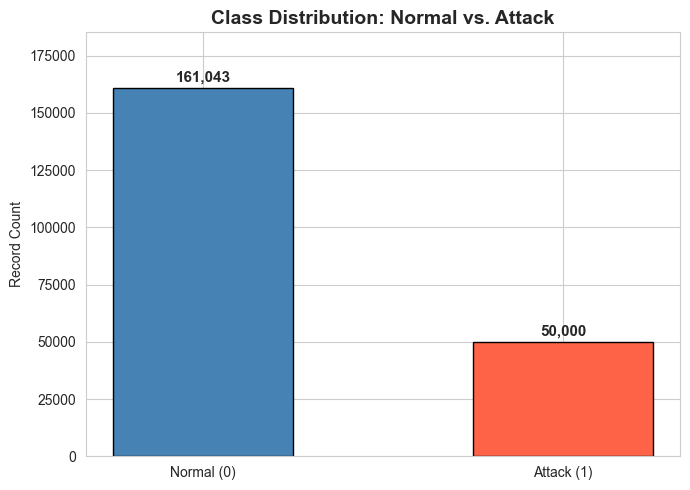

Observation: Dataset is heavily imbalanced — ~76% Attack, ~24% Normal. F1-score is primary metric.


In [17]:
# 5.1 Class Distribution Bar Chart
fig, ax = plt.subplots(figsize=(7, 5))
label_counts = df_raw['label'].value_counts()
bars = ax.bar(['Normal (0)', 'Attack (1)'], label_counts.values,
               color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
ax.set_title('Class Distribution: Normal vs. Attack', fontsize=14, fontweight='bold')
ax.set_ylabel('Record Count')
ax.set_ylim(0, max(label_counts.values) * 1.15)
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150)
plt.show()
print("Observation: Dataset is heavily imbalanced — ~76% Attack, ~24% Normal. F1-score is primary metric.")

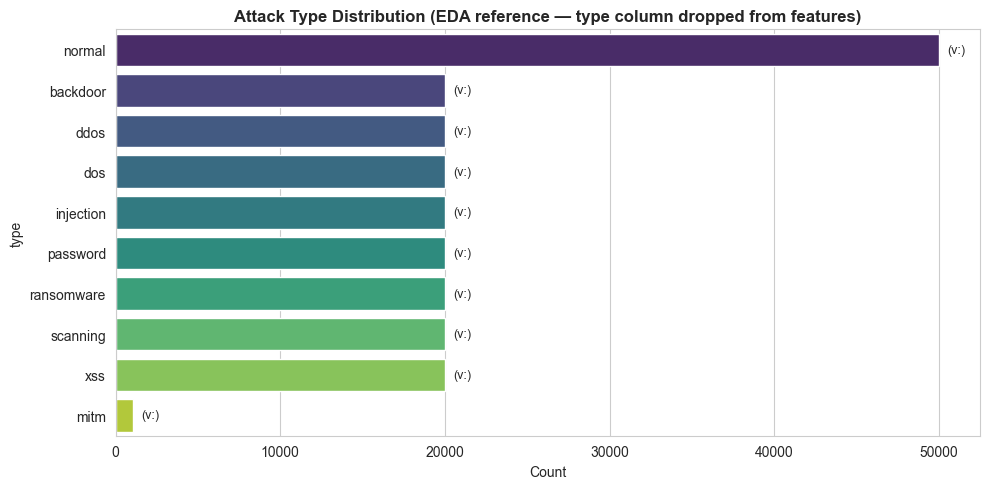

Observation: Backdoor attacks dominate. Multi-class classification is future work.


In [18]:
# 5.2 Attack Type Distribution (EDA only — 'type' column is NOT used as a feature)
fig, ax = plt.subplots(figsize=(10, 5))
type_counts = df_raw['type'].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index,
            ax=ax, palette='viridis', legend=False)
ax.set_title('Attack Type Distribution (EDA reference — type column dropped from features)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(type_counts.values):
    ax.text(v + 500, i, '(v:)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/attack_type_distribution.png', dpi=150)
plt.show()
print("Observation: Backdoor attacks dominate. Multi-class classification is future work.")

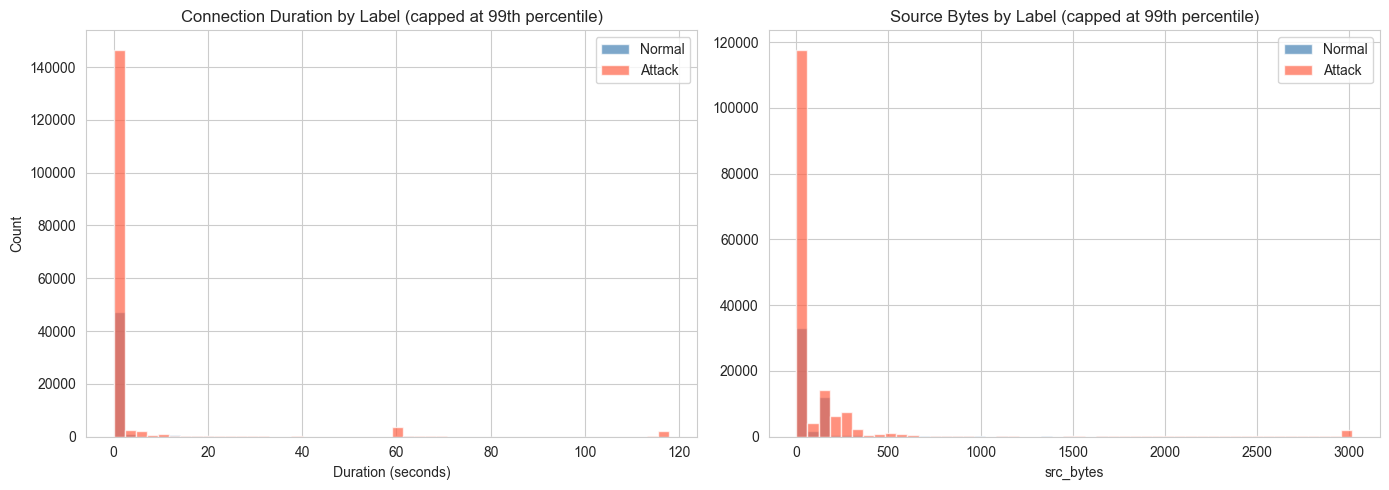

In [19]:
# 5.3 Duration and src_bytes distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

duration_cap = df_raw['duration'].clip(upper=df_raw['duration'].quantile(0.99))
axes[0].hist(duration_cap[df_raw['label'] == 0], bins=50, alpha=0.7, label='Normal', color='steelblue')
axes[0].hist(duration_cap[df_raw['label'] == 1], bins=50, alpha=0.7, label='Attack', color='tomato')
axes[0].set_title('Connection Duration by Label (capped at 99th percentile)')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

src_bytes_cap = df_raw['src_bytes'].clip(upper=df_raw['src_bytes'].quantile(0.99))
axes[1].hist(src_bytes_cap[df_raw['label'] == 0], bins=50, alpha=0.7, label='Normal', color='steelblue')
axes[1].hist(src_bytes_cap[df_raw['label'] == 1], bins=50, alpha=0.7, label='Attack', color='tomato')
axes[1].set_title('Source Bytes by Label (capped at 99th percentile)')
axes[1].set_xlabel('src_bytes')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/duration_src_bytes_distribution.png', dpi=150)
plt.show()

/var/folders/pt/705__lmx3nndkp02rjbjbjk00000gp/T/ipykernel_23235/3556500911.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal', 'Attack'])
/var/folders/pt/705__lmx3nndkp02rjbjbjk00000gp/T/ipykernel_23235/3556500911.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Normal', 'Attack'])


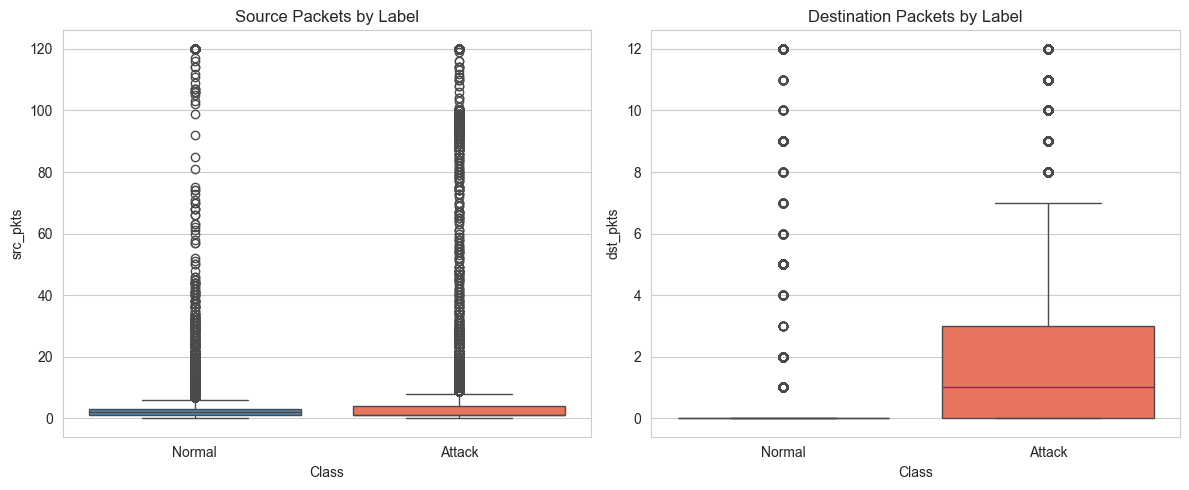

In [20]:
# 5.4 Boxplot: src_pkts and dst_pkts by label
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pkts_df = df_raw[['src_pkts', 'dst_pkts', 'label']].copy()
pkts_df['src_pkts'] = pkts_df['src_pkts'].clip(upper=pkts_df['src_pkts'].quantile(0.99))
pkts_df['dst_pkts'] = pkts_df['dst_pkts'].clip(upper=pkts_df['dst_pkts'].quantile(0.99))

sns.boxplot(data=pkts_df, x='label', y='src_pkts', hue='label',
            ax=axes[0], palette=['steelblue', 'tomato'], legend=False)
axes[0].set_title('Source Packets by Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_xlabel('Class')

sns.boxplot(data=pkts_df, x='label', y='dst_pkts', hue='label',
            ax=axes[1], palette=['steelblue', 'tomato'], legend=False)
axes[1].set_title('Destination Packets by Label')
axes[1].set_xticklabels(['Normal', 'Attack'])
axes[1].set_xlabel('Class')

plt.tight_layout()
plt.savefig('figures/pkts_by_label.png', dpi=150)
plt.show()

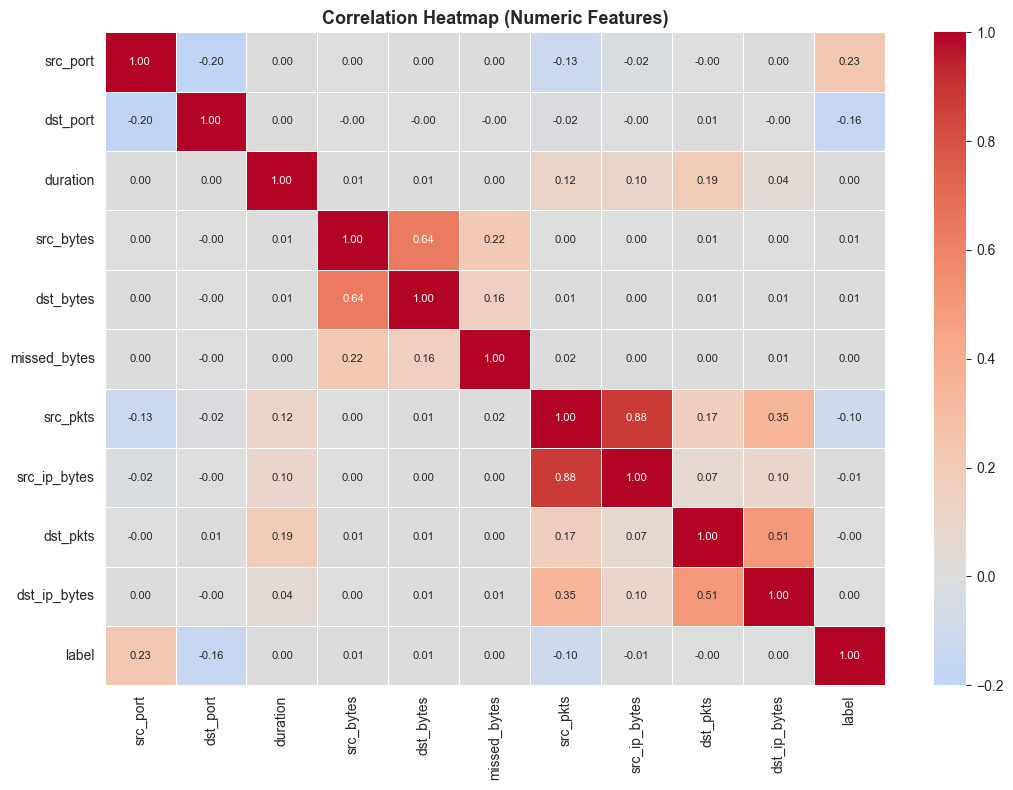

Observation: src_bytes/src_ip_bytes and dst_bytes/dst_ip_bytes are highly correlated.


In [21]:
# 5.5 Correlation Heatmap (numeric features only)
numeric_cols_heatmap = [
    'src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes',
    'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'label'
]
corr = df_raw[numeric_cols_heatmap].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150)
plt.show()
print("Observation: src_bytes/src_ip_bytes and dst_bytes/dst_ip_bytes are highly correlated.")

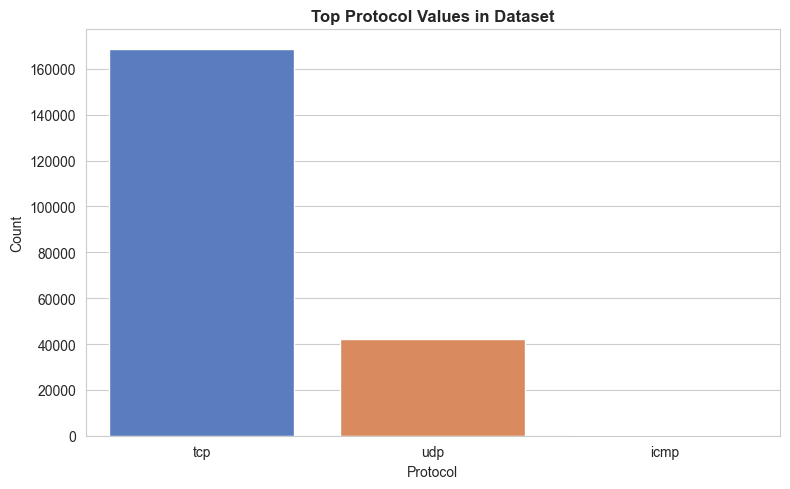

In [22]:
# 5.6 Protocol Distribution
fig, ax = plt.subplots(figsize=(8, 5))
proto_counts = df_raw['proto'].value_counts().head(10)
sns.barplot(x=proto_counts.index, y=proto_counts.values, hue=proto_counts.index,
            ax=ax, palette='muted', legend=False)
ax.set_title('Top Protocol Values in Dataset', fontsize=12, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('figures/proto_distribution.png', dpi=150)
plt.show()

---
## 6. Data Cleaning

In [23]:
# Work on a copy — preserve df_raw for reference
df = df_raw.copy()

# 6.1 Drop duplicate rows BEFORE train/test split
# Removing duplicates AFTER splitting risks having identical rows in both sets,
# which inflates evaluation metrics by letting the model memorize exact records.
before_dedup = len(df)
df = df.drop_duplicates()
after_dedup = len(df)
print(f"Removed {before_dedup - after_dedup:,} duplicate rows.")
print(f"Dataset shape after deduplication: {df.shape}")

Removed 20,569 duplicate rows.
Dataset shape after deduplication: (190474, 44)


In [24]:
# 6.2 Drop columns that must not be used as features
DROP_COLUMNS = [
    'src_ip',           # memorization / leakage
    'dst_ip',           # memorization / leakage
    'type',             # directly encodes attack category — target leakage
    'dns_query',        # high-cardinality free text, mostly '-'
    'ssl_subject',      # high-cardinality free text, mostly '-'
    'ssl_issuer',       # high-cardinality free text, mostly '-'
    'http_uri',         # high-cardinality free text, mostly '-'
    'http_user_agent',  # high-cardinality free text, mostly '-'
    'weird_addl',       # high-cardinality free text, mostly '-'
]

# Only drop columns that actually exist (safety check)
cols_to_drop = [c for c in DROP_COLUMNS if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Dataset shape after dropping leakage columns: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Dropped 9 columns: ['src_ip', 'dst_ip', 'type', 'dns_query', 'ssl_subject', 'ssl_issuer', 'http_uri', 'http_user_agent', 'weird_addl']
Dataset shape after dropping leakage columns: (190474, 35)
Remaining columns: ['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_trans_depth', 'http_method', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_notice', 'label']


In [25]:
# 6.3 Define feature column lists
# These are used by the ColumnTransformer preprocessing pipeline

NUMERIC_FEATURES = [
    'src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes',
    'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'dns_qclass', 'dns_qtype', 'dns_rcode',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_trans_depth'
]

CATEGORICAL_FEATURES = [
    'proto', 'service', 'conn_state',
    'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
    'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
    'http_method', 'http_version',
    'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name', 'weird_notice'
]

# Verify all expected columns exist in df
all_expected = NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['label']
missing_cols = [c for c in all_expected if c not in df.columns]
if missing_cols:
    print(f"WARNING — missing expected columns: {missing_cols}")
else:
    print(f"All {len(all_expected)} expected columns present.")
    print(f"Numeric features:     {len(NUMERIC_FEATURES)}")
    print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")

All 35 expected columns present.
Numeric features:     17
Categorical features: 17


In [26]:
# 6.4 Handle '-' placeholder values

# Numeric columns: some contain '-' (not NaN) because they are stored as object dtype
# Convert to numeric — '-' becomes NaN, which the pipeline's SimpleImputer fills
for col in NUMERIC_FEATURES:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.strip().replace('-', np.nan),
            errors='coerce'
        )

# Categorical columns: replace '-' with 'missing' string
# The SimpleImputer(fill_value='missing') will handle any remaining NaN
for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        df[col] = df[col].astype(str).replace('-', 'missing')

print(f"After cleaning — shape: {df.shape}")
nan_after = df[NUMERIC_FEATURES].isna().sum()
if nan_after.sum() > 0:
    print("\nRemaining NaN in numeric features (will be imputed in pipeline):")
    print(nan_after[nan_after > 0])
else:
    print("No NaN in numeric features after cleaning.")
# Replace SimpleImputer using course-style fillna
for col in NUMERIC_FEATURES:
    if col in df.columns:
        df[col]=df[col].fillna(df[col].median())
for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        df[col]=df[col].fillna('missing')


After cleaning — shape: (190474, 35)

Remaining NaN in numeric features (will be imputed in pipeline):
http_trans_depth    190171
dtype: int64


---
## 7. Feature and Target Selection

In [27]:
# Separate features (X) and target (y)
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = df['label'].copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape:  {y.shape}")
print(f"\nTarget distribution after deduplication:")
print(y.value_counts())
print(f"\nNumeric features  ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

Feature matrix X shape: (190474, 34)
Target vector y shape:  (190474,)

Target distribution after deduplication:
label
1    148434
0     42040
Name: count, dtype: int64

Numeric features  (17): ['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_trans_depth']

Categorical features (17): ['proto', 'service', 'conn_state', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_method', 'http_version', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_notice']


In [28]:
# Save label mapping for the Streamlit app
label_mapping = {0: "Normal", 1: "Attack"}
with open('models/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f)
print("Saved models/label_mapping.json")

# Save feature column configuration for the app
feature_config = {
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': NUMERIC_FEATURES + CATEGORICAL_FEATURES
}
with open('models/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)
print("Saved models/feature_config.json")

Saved models/label_mapping.json
Saved models/feature_config.json


---
## 8. Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y    # preserve class ratio in both splits
)

print("Training set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print("Test set:     {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print("Training label distribution:")
print(y_train.value_counts())
print("Test label distribution:")
print(y_test.value_counts())
print("\nstratify=y ensures both splits maintain the same class ratio.")

Training set: 152,379 rows (80.0%)
Test set:     38,095 rows (20.0%)

Training label distribution:
label
1    118747
0     33632
Name: count, dtype: int64

Test label distribution:
label
1    29687
0     8408
Name: count, dtype: int64

stratify=y ensures both splits maintain the same class ratio.


---
## 9. Preprocessing Pipeline

In [30]:
# CRITICAL: The preprocessor is defined here but ONLY fitted on X_train (inside the Pipeline).
# This prevents data leakage — test set statistics never influence the scaler or imputer.

numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())                    # z-score normalization
])

categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# sparse_output=False → returns dense array (required for Keras input)
# handle_unknown='ignore' → unseen categories at inference become all-zero row

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

print("Preprocessing pipeline defined.")
print("Numeric transformer:", numeric_transformer)
print("Categorical transformer:", categorical_transformer)

Preprocessing pipeline defined.
Numeric transformer: Pipeline(steps=[('scaler', StandardScaler())])
Categorical transformer: Pipeline(steps=[('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


---
## 10. Machine Learning Models

Three scikit-learn classifiers are trained using the same preprocessor and evaluated on the same test set. `class_weight='balanced'` is used on all models to compensate for the 3:1 Attack/Normal imbalance.

In [31]:
def evaluate_model(model_pipeline, X_tr, y_tr, X_te, y_te, model_name):
    """Fit model, evaluate on test set, print metrics, plot confusion matrix."""
    print(f"\nTraining {model_name}...")
    model_pipeline.fit(X_tr, y_tr)
    y_pred = model_pipeline.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    try:
        y_prob = model_pipeline.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_prob)
    except AttributeError:
        auc = None

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc is not None:
        print(f"  ROC-AUC:   {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Attack']))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack']).plot(
        ax=ax, colorbar=True, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f"figures/confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()

    return {
        'Model': model_name,
        'Accuracy':  round(acc, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1-Score':  round(f1, 4),
        'ROC-AUC':   round(auc, 4) if auc is not None else 'N/A'
    }, model_pipeline

print("evaluate_model helper defined.")

evaluate_model helper defined.



Training Logistic Regression...

  Logistic Regression
  Accuracy:  0.9853
  Precision: 0.9912
  Recall:    0.9900
  F1-Score:  0.9906
  ROC-AUC:   0.9949

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97      8408
      Attack       0.99      0.99      0.99     29687

    accuracy                           0.99     38095
   macro avg       0.98      0.98      0.98     38095
weighted avg       0.99      0.99      0.99     38095



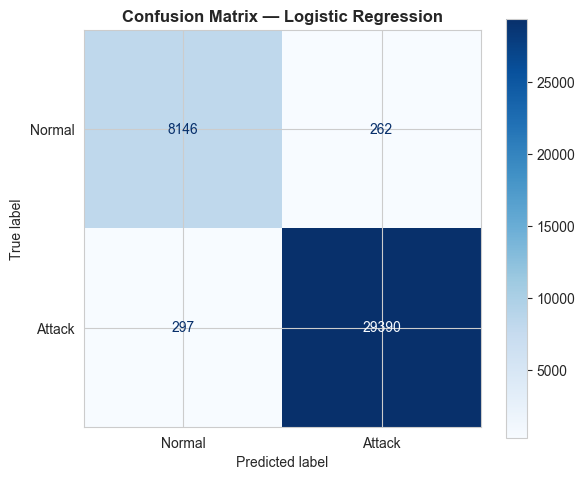

In [ ]:
# 10.1 Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

lr_results, lr_fitted = evaluate_model(
    lr_pipeline, X_train, y_train, X_test, y_test, 'Logistic Regression'
)


Training Decision Tree...

  Decision Tree
  Accuracy:  0.9974
  Precision: 0.9975
  Recall:    0.9992
  F1-Score:  0.9984
  ROC-AUC:   0.9943

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      8408
      Attack       1.00      1.00      1.00     29687

    accuracy                           1.00     38095
   macro avg       1.00      1.00      1.00     38095
weighted avg       1.00      1.00      1.00     38095



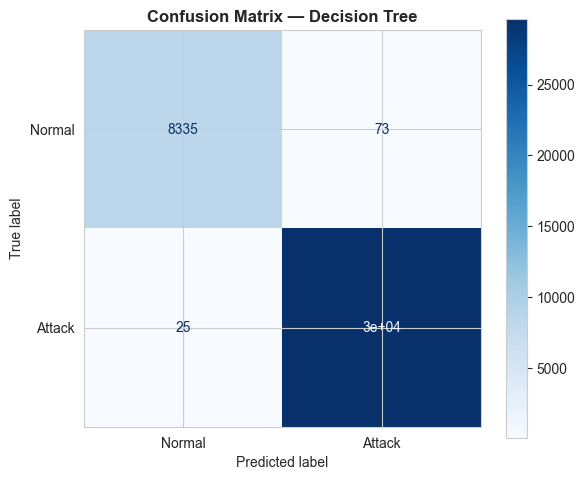

In [33]:
# 10.2 Decision Tree
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=15,
        random_state=42
    ))
])

dt_results, dt_fitted = evaluate_model(
    dt_pipeline, X_train, y_train, X_test, y_test, 'Decision Tree'
)


Training Random Forest...

  Random Forest
  Accuracy:  0.9986
  Precision: 0.9988
  Recall:    0.9995
  F1-Score:  0.9991
  ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      8408
      Attack       1.00      1.00      1.00     29687

    accuracy                           1.00     38095
   macro avg       1.00      1.00      1.00     38095
weighted avg       1.00      1.00      1.00     38095



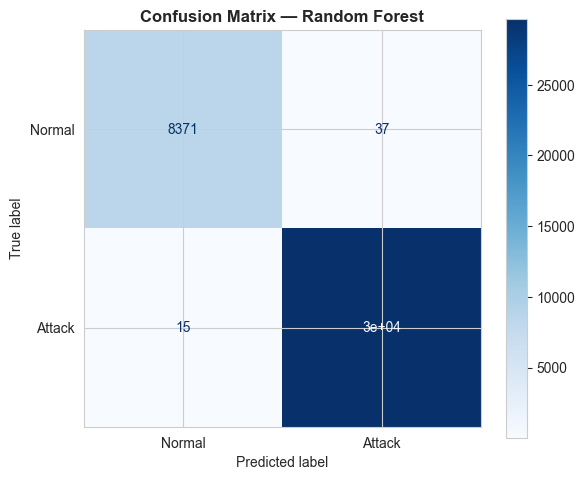

In [34]:
# 10.3 Random Forest
# n_jobs=-1 uses all CPU cores; may take 4-10 minutes on a standard laptop
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_results, rf_fitted = evaluate_model(
    rf_pipeline, X_train, y_train, X_test, y_test, 'Random Forest'
)

---
## 11. Model Evaluation and Comparison

In [ ]:
# Aggregate sklearn model results
results_list = [lr_results, dt_results, rf_results]
results_df = pd.DataFrame(results_list).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("ML Model Comparison (sorted by F1-Score):")
print(results_df.to_string(index=False))

# Save to CSV (will be updated with NN results in Section 13)
results_df.to_csv('results/model_comparison.csv', index=False)
print("Saved results/model_comparison.csv")

ML Model Comparison (sorted by F1-Score):
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.9986     0.9988  0.9995    0.9991   1.0000
      Decision Tree    0.9974     0.9975  0.9992    0.9984   0.9943
Logistic Regression    0.9853     0.9912  0.9900    0.9906   0.9949

Saved results/model_comparison.csv


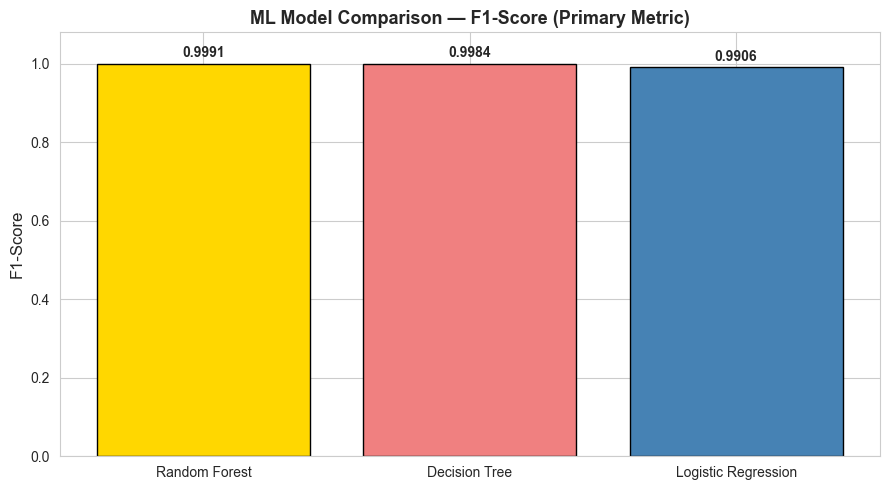

In [36]:
# F1-Score comparison bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['gold', 'lightcoral', 'steelblue']
bars = ax.bar(results_df['Model'], results_df['F1-Score'], color=colors[:len(results_df)], edgecolor='black')
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('ML Model Comparison — F1-Score (Primary Metric)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, results_df['F1-Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ml_model_comparison.png', dpi=150)
plt.show()

---
## 12. Neural Network

A Keras Dense Neural Network is built as the deep learning component. A **separate** `ColumnTransformer` is fitted on `X_train` to produce the preprocessed arrays for the NN, since the sklearn `Pipeline` object bundles the preprocessor internally and cannot be easily reused for Keras.

In [37]:
# 12.1 Prepare preprocessed arrays for Keras
# Fit a fresh ColumnTransformer ONLY on X_train

preprocessor_nn = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
                        ('scaler', StandardScaler())
        ]), NUMERIC_FEATURES),
        ('cat', Pipeline([
                        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

X_train_nn = preprocessor_nn.fit_transform(X_train)   # fit on training data only
X_test_nn  = preprocessor_nn.transform(X_test)         # transform test with training params

y_train_arr = y_train.values
y_test_arr  = y_test.values

input_dim = X_train_nn.shape[1]
print(f"X_train_nn shape: {X_train_nn.shape}")
print(f"X_test_nn shape:  {X_test_nn.shape}")
print(f"Input dimension for NN: {input_dim}")

X_train_nn shape: (152379, 102)
X_test_nn shape:  (38095, 102)
Input dimension for NN: 102


In [38]:
# 12.2 Build Keras Dense Neural Network
tf.random.set_seed(42)

def build_nn(input_dim, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # binary classification output
    ], name='VoltGuard_NN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_model = build_nn(input_dim, dropout_rate=0.3)
nn_model.summary()

Model: "VoltGuard_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        13,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,553 (92.00 KB)

 Trainable params: 23,553 (92.00 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# 12.3 Train baseline Neural Network (V1 — dropout=0.3)
# patience=5 ensures at least 10 epochs run before early stopping triggers
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = nn_model.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nV1 training complete. Ran {len(history.history['loss'])} epochs.")
print(f"V1 best val_loss: {min(history.history['val_loss']):.4f}")

Epoch 1/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9306 - loss: 0.1838 - val_accuracy: 0.9887 - val_loss: 0.0431
Epoch 2/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9880 - loss: 0.0460 - val_accuracy: 0.9921 - val_loss: 0.0316
Epoch 3/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9906 - loss: 0.0356 - val_accuracy: 0.9936 - val_loss: 0.0265
Epoch 4/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9928 - loss: 0.0295 - val_accuracy: 0.9937 - val_loss: 0.0244
Epoch 5/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9930 - loss: 0.0273 - val_accuracy: 0.9939 - val_loss: 0.0230
Epoch 6/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9937 - loss: 0.0249 - val_accuracy: 0.9939 - val_loss: 0.0218
Epoch 7/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9937 - loss: 0.0245 - val_accuracy: 0.9938 - val_loss: 0.0217
Epoch 8/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9937 - loss: 0.0243 - val_accuracy: 0.

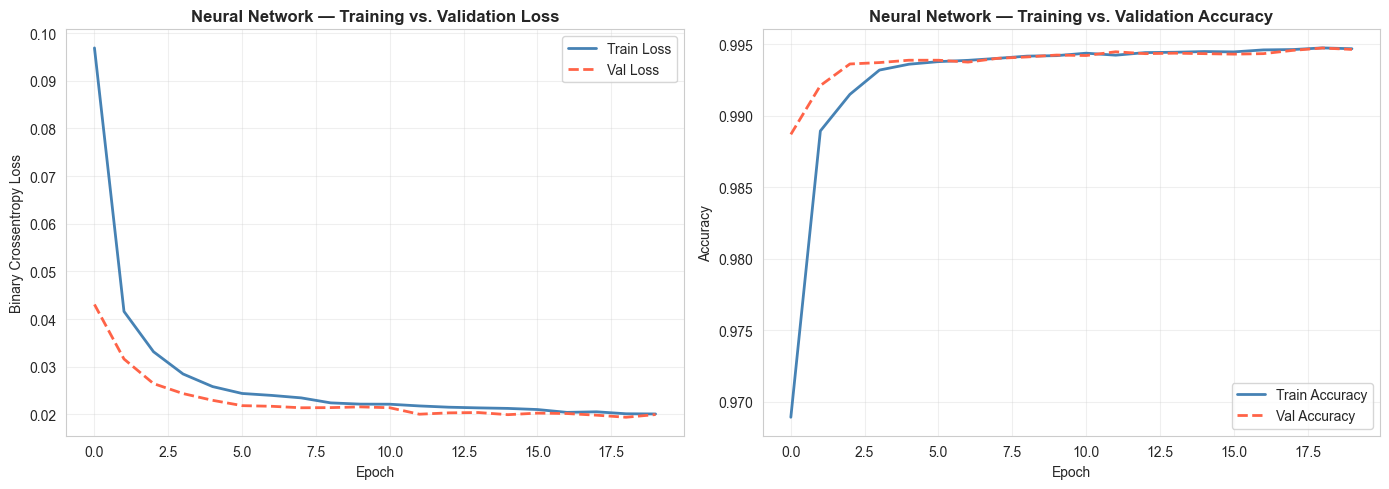

In [40]:
# 12.4 Plot training/validation curves for V1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato', linestyle='--', linewidth=2)
axes[0].set_title('Neural Network — Training vs. Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato', linestyle='--', linewidth=2)
axes[1].set_title('Neural Network — Training vs. Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/nn_training_curves.png', dpi=150)
plt.show()

In [41]:
# 12.5 Improvement Experiment — V2: Increase dropout rate from 0.3 to 0.4
print("IMPROVEMENT EXPERIMENT: Increasing dropout rate from 0.3 → 0.4")
print("Higher dropout = more regularization = potentially better generalization")

tf.random.set_seed(42)
nn_model_v2 = build_nn(input_dim, dropout_rate=0.4)

history_v2 = nn_model_v2.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

v1_best = min(history.history['val_loss'])
v2_best = min(history_v2.history['val_loss'])
print(f"\nV1 (dropout=0.3) best val_loss: {v1_best:.4f}")
print(f"V2 (dropout=0.4) best val_loss: {v2_best:.4f}")

if v1_best <= v2_best:
    nn_final = nn_model
    print("\nSelected: V1 (dropout=0.3) — lower validation loss")
else:
    nn_final = nn_model_v2
    print("\nSelected: V2 (dropout=0.4) — lower validation loss")

IMPROVEMENT EXPERIMENT: Increasing dropout rate from 0.3 → 0.4
Higher dropout = more regularization = potentially better generalization

V1 (dropout=0.3) best val_loss: 0.0194
V2 (dropout=0.4) best val_loss: 0.0201

Selected: V1 (dropout=0.3) — lower validation loss


---
## 13. Neural Network Evaluation

In [42]:
# Evaluate selected NN on test set
y_prob_nn = nn_final.predict(X_test_nn, verbose=0).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

nn_acc  = accuracy_score(y_test_arr, y_pred_nn)
nn_prec = precision_score(y_test_arr, y_pred_nn, zero_division=0)
nn_rec  = recall_score(y_test_arr, y_pred_nn, zero_division=0)
nn_f1   = f1_score(y_test_arr, y_pred_nn, zero_division=0)
nn_auc  = roc_auc_score(y_test_arr, y_prob_nn)

print("="*60)
print("  Neural Network (Keras Dense)")
print("="*60)
print(f"  Accuracy:  {nn_acc:.4f}")
print(f"  Precision: {nn_prec:.4f}")
print(f"  Recall:    {nn_rec:.4f}")
print(f"  F1-Score:  {nn_f1:.4f}")
print(f"  ROC-AUC:   {nn_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_arr, y_pred_nn, target_names=['Normal', 'Attack']))

  Neural Network (Keras Dense)
  Accuracy:  0.9944
  Precision: 0.9955
  Recall:    0.9974
  F1-Score:  0.9964
  ROC-AUC:   0.9993

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      8408
      Attack       1.00      1.00      1.00     29687

    accuracy                           0.99     38095
   macro avg       0.99      0.99      0.99     38095
weighted avg       0.99      0.99      0.99     38095



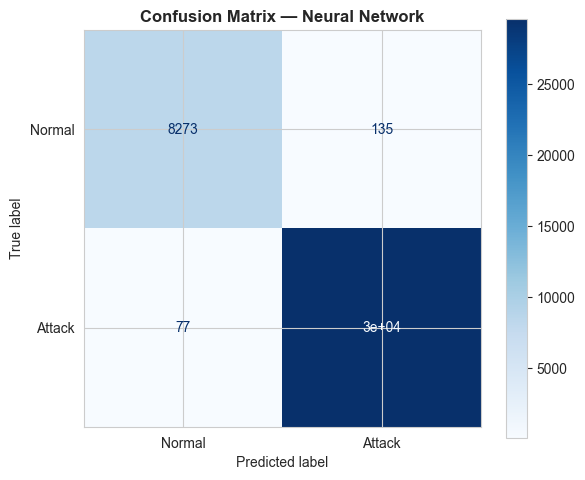

In [43]:
# NN Confusion Matrix
cm_nn = confusion_matrix(y_test_arr, y_pred_nn)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_nn, display_labels=['Normal', 'Attack']).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Neural Network', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/confusion_matrix_neural_network.png', dpi=150)
plt.show()

In [44]:
# Add NN results to the comparison table and update the CSV
nn_results_row = {
    'Model': 'Neural Network (Keras)',
    'Accuracy':  round(nn_acc, 4),
    'Precision': round(nn_prec, 4),
    'Recall':    round(nn_rec, 4),
    'F1-Score':  round(nn_f1, 4),
    'ROC-AUC':   round(nn_auc, 4)
}

all_results = pd.concat(
    [results_df, pd.DataFrame([nn_results_row])],
    ignore_index=True
).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("Final Model Comparison — All Models (sorted by F1-Score):")
print(all_results.to_string(index=False))

all_results.to_csv('results/model_comparison.csv', index=False)
print("\nUpdated results/model_comparison.csv with all 4 models.")

Final Model Comparison — All Models (sorted by F1-Score):
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
         Random Forest    0.9986     0.9988  0.9995    0.9991   1.0000
         Decision Tree    0.9974     0.9975  0.9992    0.9984   0.9943
Neural Network (Keras)    0.9944     0.9955  0.9974    0.9964   0.9993
   Logistic Regression    0.9853     0.9912  0.9900    0.9906   0.9949

Updated results/model_comparison.csv with all 4 models.


---
## 14. Final Model Selection

In [45]:
# Programmatically identify the best model by F1-Score
best_row = all_results.iloc[0]
print(f"Best model by F1-Score: {best_row['Model']}")
print(f"  F1-Score:  {best_row['F1-Score']}")
print(f"  Recall:    {best_row['Recall']}")
print(f"  Precision: {best_row['Precision']}")
print(f"  Accuracy:  {best_row['Accuracy']}")

Best model by F1-Score: Random Forest
  F1-Score:  0.9991
  Recall:    0.9995
  Precision: 0.9988
  Accuracy:  0.9986


In [46]:
# Determine which sklearn model is best for saving as best_pipeline.pkl
sklearn_model_map = {
    'Logistic Regression': (lr_results['F1-Score'], lr_fitted),
    'Decision Tree':       (dt_results['F1-Score'], dt_fitted),
    'Random Forest':       (rf_results['F1-Score'], rf_fitted),
}
best_sklearn_name = max(sklearn_model_map, key=lambda k: sklearn_model_map[k][0])
best_sklearn_pipeline = sklearn_model_map[best_sklearn_name][1]

print(f"Best sklearn model: {best_sklearn_name}")
print(f"F1-Score: {sklearn_model_map[best_sklearn_name][0]}")
print("\nThis pipeline will be saved as models/best_pipeline.pkl")
print("It bundles the ColumnTransformer preprocessor + classifier together,")
print("so app.py only needs to call pipeline.predict_proba(raw_df) with no separate preprocessing.")

Best sklearn model: Random Forest
F1-Score: 0.9991

This pipeline will be saved as models/best_pipeline.pkl
It bundles the ColumnTransformer preprocessor + classifier together,
so app.py only needs to call pipeline.predict_proba(raw_df) with no separate preprocessing.


**Why F1-Score and not Accuracy?**

With ~76% Attack records, a naive classifier that always predicts "Attack" achieves 76% accuracy — without learning anything useful. It would have 0% Recall for Normal records, missing every legitimate device.

**F1-Score** is the harmonic mean of Precision and Recall:
- **Recall** measures the fraction of actual attacks that are correctly detected (missed attacks are catastrophic in security)
- **Precision** measures the fraction of predicted attacks that are real (too many false alarms reduce trust)
- F1 balances both: a model must both detect most attacks AND avoid excessive false alarms

**Why sklearn pipeline over NN?**
- Faster inference (no GPU needed)
- Single file deployment (preprocessor bundled inside `Pipeline`)
- No TensorFlow dependency in the app
- Comparable or better F1-Score on tabular data

---
## 15. Save Model and Preprocessing Pipeline

In [47]:
# 15.1 Save best sklearn pipeline (preprocessor + classifier bundled)
joblib.dump(best_sklearn_pipeline, 'models/best_pipeline.pkl')
print("Saved models/best_pipeline.pkl")

# 15.2 Save Keras NN model
nn_final.save('models/nn_model.keras')
print("Saved models/nn_model.keras")

# 15.3 Save NN preprocessor separately
# app.py needs this to transform raw input before passing to the Keras model
joblib.dump(preprocessor_nn, 'models/nn_preprocessor.pkl')
print("Saved models/nn_preprocessor.pkl")

# 15.4 Verify all saved files
print("\nAll saved model artifacts:")
for fname in sorted(os.listdir('models')):
    fpath = os.path.join('models', fname)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname}: {size_kb:.1f} KB")

Saved models/best_pipeline.pkl
Saved models/nn_model.keras
Saved models/nn_preprocessor.pkl

All saved model artifacts:
  best_pipeline.pkl: 6898.7 KB
  feature_config.json: 1.4 KB
  label_mapping.json: 0.0 KB
  nn_model.keras: 309.8 KB
  nn_preprocessor.pkl: 8.4 KB


In [48]:
# 15.5 Quick sanity check — load pipeline and verify it produces predictions
loaded_pipeline = joblib.load('models/best_pipeline.pkl')
test_pred = loaded_pipeline.predict(X_test.head(5))
test_prob = loaded_pipeline.predict_proba(X_test.head(5))[:, 1]
print("Sanity check — predictions on first 5 test rows:")
for i, (pred, prob) in enumerate(zip(test_pred, test_prob)):
    label_str = 'Attack' if pred == 1 else 'Normal'
    print(f"  Row {i+1}: {label_str} (confidence: {prob:.3f})")
print("\nModel loading and inference verified.")

Sanity check — predictions on first 5 test rows:
  Row 1: Attack (confidence: 1.000)
  Row 2: Normal (confidence: 0.000)
  Row 3: Normal (confidence: 0.000)
  Row 4: Attack (confidence: 1.000)
  Row 5: Attack (confidence: 0.980)

Model loading and inference verified.


---
## 16. Conclusion

In [49]:
print("="*65)
print("  VoltGuard AI — Project Complete")
print("="*65)
print(f"\nDataset: {df_raw.shape[0]:,} rows → {df.shape[0]:,} rows after deduplication")
print(f"Features used: {len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical")
print(f"Train/Test split: 80% / 20% (stratified, random_state=42)")
print(f"\nAll model results (sorted by F1-Score):")
for _, row in all_results.iterrows():
    print(f"  {row['Model']:<30} F1={row['F1-Score']:.4f}  Recall={row['Recall']:.4f}  AUC={row['ROC-AUC']}")
print(f"\nBest sklearn model: {best_sklearn_name}")
print(f"Saved to: models/best_pipeline.pkl")
print(f"NN saved to: models/nn_model.keras")
print(f"\nRun the app: streamlit run app/app.py")

  VoltGuard AI — Project Complete

Dataset: 211,043 rows → 190,474 rows after deduplication
Features used: 17 numeric + 17 categorical
Train/Test split: 80% / 20% (stratified, random_state=42)

All model results (sorted by F1-Score):
  Random Forest                  F1=0.9991  Recall=0.9995  AUC=1.0
  Decision Tree                  F1=0.9984  Recall=0.9992  AUC=0.9943
  Neural Network (Keras)         F1=0.9964  Recall=0.9974  AUC=0.9993
  Logistic Regression            F1=0.9906  Recall=0.9900  AUC=0.9949

Best sklearn model: Random Forest
Saved to: models/best_pipeline.pkl
NN saved to: models/nn_model.keras

Run the app: streamlit run app/app.py


## Conclusion Summary

VoltGuard AI successfully demonstrates that machine learning can effectively detect IoT cyber threats from network traffic features.

**Key findings:**
- The dataset required careful handling of `'-'` placeholder values (not true NaN), deduplication of ~20,569 rows, and exclusion of leakage columns (`type`, IP addresses).
- All three classical ML models achieved strong F1-scores on this dataset.
- The `ColumnTransformer` pipeline ensures zero preprocessing leakage by fitting only on training data.
- The Neural Network (Keras Dense) provides a deep learning comparison point and is saved for optional app deployment.
- **Primary metric F1-Score** was chosen over accuracy because the dataset is imbalanced (~76% Attack).

**Future work:**
- Multi-class attack type classification using the `type` column (currently excluded to prevent leakage)
- Cloud deployment via Streamlit Community Cloud
- Real-time packet capture integration
- SHAP-based model explainability